# Number of Target Estimation with AIC and MDL

A significant number of DoA estimation methods are required to know the number of targets before a meaningful DoA estimation process. This information is not present in every situation. Assume the case where we need to implement a DoA estimation process in a base station for mobile communication and we decide to go with ESPRIT. How many devices attempt to connect with the base station? We will never have this information known at any point in the base station's operation time. 

On the other hand, we cannot let the lack of information on number of targets render our algorithms useless; after all, we still have to detect and locate targets. Imagine you are tasked to design a radar that detects fast-flying artillery and mortar rounds (yes, these things exist! They are called *counter-battery radar* in technical jargon, look at this one as an example; [AN/MPQ-64 Sentinel](https://en.wikipedia.org/wiki/AN/MPQ-64_Sentinel)). I don't think this will be a scenario where you would like to say play the "technically not possible" card, for the safety of everyone under the risk. 

We need a proxy if not the exact number of targets. How can we have this knowledge with our receiver readings? In this notebook you will be introduced to a very simple estimation method that relies on the same priors as our DoA estimation methods.

In [ ]:
# Importing modules
import numpy as np; 
import matplotlib.pyplot as plt; 

# np.random.seed(42); # In order to ensure reproducibility. You can use different seed values.

In [2]:
# Defining methods
hermitian = lambda array: np.conj(array).T; 


def g_mean(arr): # Geometric mean function
  g = 1; 
  for i in range(len(arr)):
    g = g*arr[i]; 
  return g**(1/len(arr)); 


def a_mean(arr): # Arithmetic mean function
  a = 0; 
  for i in range(len(arr)):
    a = a+arr[i]; 
  return a/len(arr); 


def steering_vector(sensor_pos: np.ndarray, ang_elev: float, ang_azim: float, wavelen: float) -> np.ndarray:
  omega = np.array([[np.sin(ang_elev)*np.cos(ang_azim)],
                    [np.sin(ang_elev)*np.sin(ang_azim)],
                    [np.cos(ang_elev)]]); 
  return np.exp(1j*2*np.pi/wavelen*sensor_pos.T@omega); 


def generate_pos_1d_ula(
    N: int,
    d: float,
    axis=(1.,0.,0.),
    x_init=(0.,0.,0.)
    ) -> np.ndarray:
  if len(axis) != 3:
    raise TypeError(f"""The axis argument represents a 3D Cartesian vector.
      The length of the input ({len(axis)}) does not match with expected
      size 3."""); 
  if sum(axis) != 1:
    axis_new = (x/sum(axis) for x in axis); 
    axis = axis_new; 

  if len(x_init) != 3:
    raise TypeError(f"""The x_init argument represents a 3D cartesian vector.
      The length of the input ({len(x_init)}) does not match with expected
      size 3."""); 

  sensor_pos = np.tile(x_init, N).reshape(N,3).T \
    + (np.arange(0,N,1)*d) * np.tile(np.array(axis), N).reshape(N,3).T; 
  return sensor_pos; 


def generate_random_targets(ang_min: float, ang_max: float, ang_dist: float, K: int) -> np.ndarray:
  is_valid = False; 
  while not is_valid:
    angs = np.random.uniform(ang_min, ang_max, K); 
    angs_sort = np.sort(angs); 
    for i in range(K-1):  # break for if is not valid
      is_valid = np.abs(angs_sort[i+1] - angs_sort[i]) >= ang_dist; 
  return angs; 

## Benchmark Methods: MVDR, MUSIC, ESPRIT

In this example, we will compare the behavior of MVDR with that of MUSIC and ESPRIT in the target number mismatch scenario. We already established that MUSIC and ESPRIT depend on the exact and true knowledge of $K$. We will now investigate the scenarios where this is not the case.

In [3]:
# Benchmark methods
def doa_est_capon(theta_scan: np.ndarray, sensor_pos: np.ndarray, R_xx: np.ndarray, wl: float) -> np.ndarray:
  Rxx_inv = np.linalg.inv(R_xx); 
  P_capon = np.zeros(len(theta_scan), dtype=np.complex128); 

  for i, theta in enumerate(theta_scan):
    bartlett = steering_vector(sensor_pos, np.deg2rad(theta), np.deg2rad(0), wl); 
    capon = (Rxx_inv @ bartlett) / (hermitian(bartlett) @ Rxx_inv @ bartlett); 
    P_capon[i] = np.squeeze(hermitian(capon) @ R_xx @ capon); 

  return P_capon; 


def doa_est_music(theta_scan: np.ndarray, sensor_pos:  np.ndarray, R_xx: np.ndarray, wl: float, K: int):
  _, e_vec = np.linalg.eigh(R_xx); 
  Un = e_vec[:, :-K]; 

  P_music = np.zeros(len(theta_scan), dtype=np.float64); 

  for i, theta in enumerate(theta_scan):
      a_theta = steering_vector(sensor_pos, np.deg2rad(theta), np.deg2rad(0), wl); 
      denominator = np.abs(a_theta.conj().T @ Un @ Un.conj().T @ a_theta); 
      P_music[i] = 1 / np.squeeze(denominator); 

  return P_music; 

def doa_est_esprit(R_xx: np.ndarray, d: float, wl: float, K: int) -> np.ndarray:
  U, _, _ = np.linalg.svd(R_xx);      # Left singular matrix
  Us = U[:, :K];                      # Signal Subspace

  # Maximally overlapping subarrays 
  U1 = Us[:-1, :];                    # First M-1 rows (Subarray 1)
  U2 = Us[1:, :];                     # Last M-1 rows (Subarray 2)

  # Total Least Squares (TLS) solution of Psi
  U12 = np.hstack((U1, U2)); 

  _, _, Vh = np.linalg.svd(U12); 
  Vh = Vh.T.conj();                   # Get right singular vectors as columns

  V12 = Vh[:K, K:]; 
  V22 = Vh[K:, K:]; 

  Psi = -V12 @ np.linalg.inv(V22); 

  eig_vals = np.linalg.eigvals(Psi);   # Complex eigenvalues of the rotation matrix
  phases = np.angle(eig_vals);         # The phases (angles) of the eigenvalues

  estimated_angles_rad = np.arcsin(phases / (2 * np.pi * (d / wl))); 
  return np.sort(np.rad2deg(estimated_angles_rad)); # returns in degrees

In [4]:
# Defining parameters
c = 3*1e8;      # The speed of light in vacuum (m/s)
f_c = 5*1e9;    # Target carrier frequency (Hz)
f_s = 100*1e9;  # Receiver sampling frequency (Hz)
wl = c/f_c;       # Signal wavelenght (m)
d = wl/2;       # Antenna distance (m)

N = 16;         # Number of antennas
T = 100;        # Number of snapshots
K = np.random.randint(4,8);          # Number of targets (selected randomly between 4 and 8)
symmetrization = False; 

S_db = [0]*K;   # Target signal power (dB)
snr_db = 0.0;   # Signal-to-Noise Ratio (dB)

ang_azim = 0;   # Azimuth angle (deg)
ang_min = -60;  # Minimum elevation angle (deg)
ang_max = 60;   # Maximum elevation angle (deg)
ang_dist = 5;   # Minimum distance between targets (deg)
ang_res = 0.1   # Angular resolution in scanning (deg)

sensor_pos = generate_pos_1d_ula(N, d);                                 # Sensor position
theta_scan = np.arange(-90,90+ang_res,ang_res);                         # Angle scan
true_angles = generate_random_targets(ang_min, ang_max, ang_dist, K);   # Target elevation angles

for k in range(K):
  print(f"Target {k} True Angle: {true_angles[k]:.3f}°"); 

Target 0 True Angle: -37.554°
Target 1 True Angle: -19.455°
Target 2 True Angle: -13.613°
Target 3 True Angle: 34.858°
Target 4 True Angle: 29.470°
Target 5 True Angle: -45.013°
Target 6 True Angle: 7.454°


In [5]:
# Data Generation
A = np.column_stack([steering_vector(sensor_pos, np.deg2rad(theta), np.deg2rad(0), wl) for theta in true_angles]); # Array Steering Matrix
S_amp = np.diag([np.sqrt(10**(s_db / 10)) for s_db in S_db]); 
S = S_amp @ (np.random.randn(K, T) + 1j*np.random.randn(K, T))/np.sqrt(2); # Target Signals: Uncorrelated Gaussian (variance = 1.0)

# Noise: Spatially white complex Gaussian noise
noise_pow = 10**(-snr_db/10); 
Noise = np.sqrt(noise_pow) * (np.random.randn(N, T) + 1j*np.random.randn(N, T))/np.sqrt(2); 

# Received Signal at the Array
X = A @ S + Noise; 

## Target Number Mismatch Scenarios
We have not discussed the effect of the wrong information on the target number. In the next two examples, we will calculate and visualize DoA estimation with MVDR (which doesn't require to know the number of targets), and compare it with the results from MUSIC and ESPRIT (that applies subspace separation based on the number of targets) in undercounted and overcounted scenarios.

If you have to guess the number of targets, the algorithms degrade rapidly.

* **Underestimating $K$**: Actual targets with lowest eigenvalues get dumped into the noise subspace. 

* **Overestimating $K$**: Some eigenvectors correlated with pure noise are accidentally promoted to the signal subspace. 

### Underestimation
In the case of undersampling, the subspace separation essentially misses the targets with lowest eigenvalues to add them into the signal subspace. This miscalculation has dire consequences for subspace-based solutions: For MUSIC, this means a real peak will be suppressed and completely missed. For ESPRIT, the missing signal will warp the rotation matrix $\bm{\Psi}$, distorting the calculated angles for the other targets.

In [ ]:
# Running the compared algorithms (MVDR, MUSIC, and ESPRIT)
from scipy.signal import find_peaks; 
Rxx_samp = (X @ X.conj().T)/T; 

P_capon = doa_est_capon(theta_scan, sensor_pos, Rxx_samp, wl); 
P_capon_dB = 10*np.log10(np.abs(np.multiply(P_capon/np.amax(P_capon), np.conjugate(P_capon/np.amax(P_capon))))); 
idx, _ = find_peaks(P_capon_dB, height=-3); 
est_capon = theta_scan[idx]; 

P_music = doa_est_music(theta_scan, sensor_pos, Rxx_samp, wl, K-2); 
P_music_dB = 10 * np.log10(P_music / np.max(P_music)); 
idx, _ = find_peaks(P_music_dB, height=-4); 
est_music = theta_scan[idx]; 

est_esprit = doa_est_esprit(Rxx_samp, d, wl, K-2); 

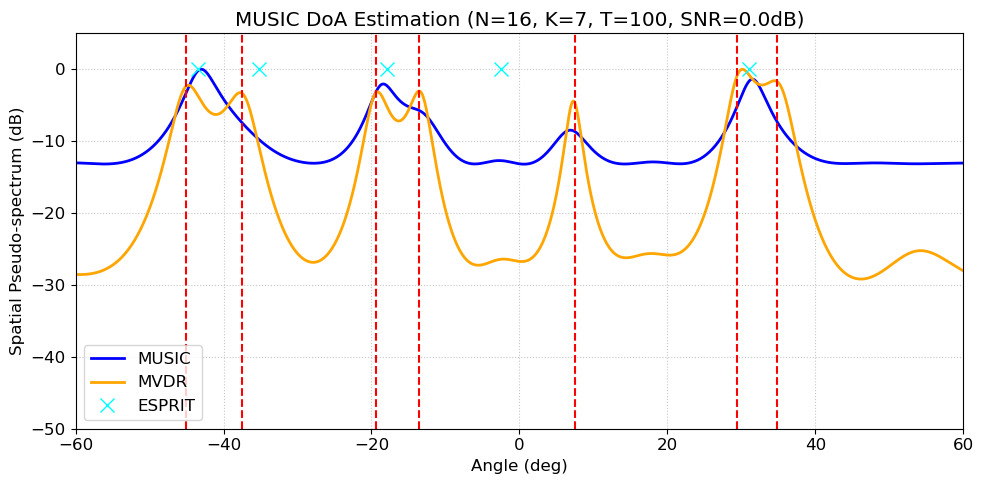

In [7]:
# Visualization
plt.rcParams.update({"font.size": 12}); 

plt.figure(figsize=(10, 5)); 
plt.plot(theta_scan, P_music_dB, linewidth=2, color="blue", label="MUSIC"); 
plt.plot(theta_scan, P_capon_dB, linewidth=2, color="orange", label="MVDR"); 

plt.plot(est_esprit, [0]*(K-2), marker='x', markersize=10, color="cyan", ls='', label="ESPRIT"); 

for i, angle in enumerate(true_angles):
  plt.axvline(x=angle, color="red", linestyle="--"); 

plt.title(f"MUSIC DoA Estimation (N={N}, K={K}, T={T}, SNR={snr_db}dB)"); 
plt.xlabel("Angle (deg)"); 
plt.ylabel("Spatial Pseudo-spectrum (dB)"); 
plt.xlim([ang_min, ang_max]); 
plt.ylim([-50, 5]); 
plt.grid(True, linestyle=':', alpha=0.7); 

handles, labels = plt.gca().get_legend_handles_labels(); 
by_label = dict(zip(labels, handles)); 
plt.legend(by_label.values(), by_label.keys(), loc="lower left"); 

plt.tight_layout(); 
plt.show(); 

### Overestimation
In the case of overestimation the number of targets, the subspace separation will include the noise eigenvectors that have the largest eigenvalues into the signal subspace. For MUSIC, this creates a "ghost peak" (a fake target) and distort the peaks of the actual signals since the orthogonality of the signal space doesn't hold exactly right. For ESPRIT, the algorithm will calculate extra eigenvalues that output totally bogus targets.

In [ ]:
P_capon = doa_est_capon(theta_scan, sensor_pos, Rxx_samp, wl); 
P_capon_dB = 10*np.log10(np.abs(np.multiply(P_capon/np.amax(P_capon), np.conjugate(P_capon/np.amax(P_capon))))); 
idx, _ = find_peaks(P_capon_dB, height=-3); 
est_capon = theta_scan[idx]; 

P_music = doa_est_music(theta_scan, sensor_pos, Rxx_samp, wl, K+2); 
P_music_dB = 10 * np.log10(P_music / np.max(P_music)); 
idx, _ = find_peaks(P_music_dB, height=-4); 
est_music = theta_scan[idx]; 

est_esprit = doa_est_esprit(Rxx_samp, d, wl, K+2); 

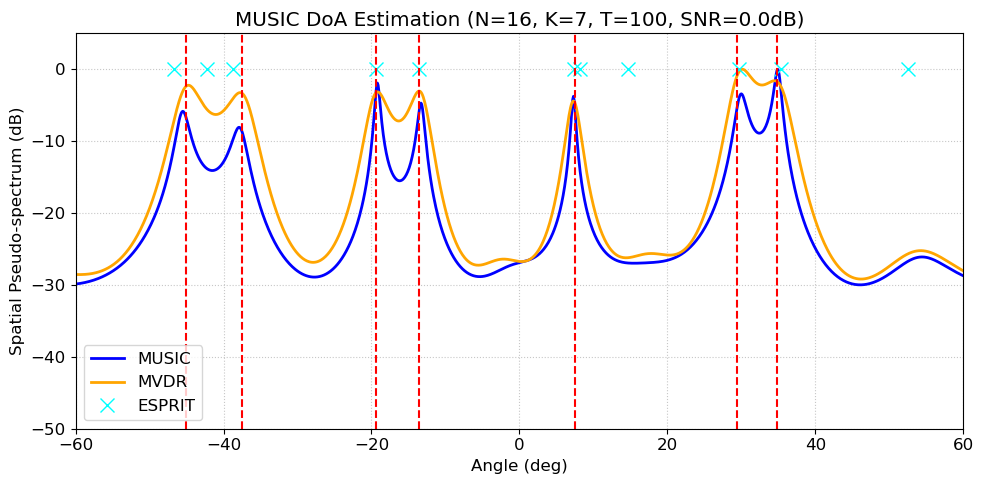

In [ ]:
# Visualization
plt.rcParams.update({"font.size": 12}); 

plt.figure(figsize=(10, 5)); 
plt.plot(theta_scan, P_music_dB, linewidth=2, color="blue", label="MUSIC"); 
plt.plot(theta_scan, P_capon_dB, linewidth=2, color="orange", label="MVDR"); 

plt.plot(est_esprit, [0]*(K+2), marker='x', markersize=10, color="cyan", ls='', label="ESPRIT"); 

for i, angle in enumerate(true_angles):
  plt.axvline(x=angle, color="red", linestyle="--"); 

plt.title(f"MUSIC DoA Estimation (N={N}, K={K}, T={T}, SNR={snr_db}dB)"); 
plt.xlabel("Angle (deg)"); 
plt.ylabel("Spatial Pseudo-spectrum (dB)"); 
plt.xlim([ang_min, ang_max]); 
plt.ylim([-50, 5]); 
plt.grid(True, linestyle=':', alpha=0.7); 

handles, labels = plt.gca().get_legend_handles_labels(); 
by_label = dict(zip(labels, handles)); 
plt.legend(by_label.values(), by_label.keys(), loc="lower left"); 

plt.tight_layout(); 
plt.show(); 

## Model Order Selection
Since targets in the real world don't politely announce themselves, radar and wireless systems must estimate $K$ before running MUSIC or ESPRIT. They do this by looking at the eigenvalue spectrum of the covariance matrix.

In a perfect, noise-free world, the K signal eigenvalues would be massively large, and the remaining M−K noise eigenvalues would be exactly zero. In the real world, the noise eigenvalues aren't zero, but they tend to cluster together at a low, flat floor representing the noise variance (σ2).

To automatically detect where that "drop-off" happens, engineers use statistical *Model Order Selection* techniques. This notebook introduces two most common ones.  

### Hermitian Symmetrization

In [ ]:
Rxx_samp = (X @ X.conj().T)/T;        # Sample (estimated) covariance
if symmetrization:                    # Hermitian Symmetrization guarantees Hermitian matrix for lower snapshot scenarios.
  Rxx_samp = 0.5*(Rxx_samp + Rxx_samp.conj().T); 
eig_val, eig_vec = np.linalg.eigh(Rxx_samp); 

## Akaike Information Criterion (AIC)

*Akaike Information Criterion* (AIC) is designed to evaluate how well a statistical model fits a set of data, with a built-in penalty for complexity. Adding more parameters to any mathematical model helps the model fit the given data better (which reduces the error). However, if there are too many parameters, the model starts including the random noise along with the underlying signal; a problem known as *overfitting*. AIC balances these two competing forces using this general formula below.

$$\text{AIC} = -2 ln(\mathcal{L}) + 2 K$$

* $-2 ln(\mathcal{L})$: This is *the goodness-of-fit (likelihood) term*. $\mathcal{L}$ is the maximized value of the likelihood function for the model. A better fit means a higher likelihood, which makes this negative term smaller (better).

* $2K$: This is *the penalty term*. $K$ is the number of estimated parameters in the model. As the model gets more complex, this term grows, increasing the AIC score.

The goal is always to find the model that minimizes the AIC score.

At first glance, the penalty term feels unproductive: if our goal is to find the true number of targets, why are we punishing the algorithm for finding more of them? To understand this, observe the likelihood term again, specifically the ratio of the geometric mean to the arithmetic mean of the "noise" eigenvalues. Without a penalty term, we would simply look for the value of $K$ that makes this goodness-of-fit term as small as possible. But here is the problem in the math: as we remove numbers from a set, the geometric and arithmetic means always get closer together. 

Imagine what happens if we guess that there are $N−1$ targets. This means we are assuming only one eigenvalue ($N−(N−1)=1$) belongs to the noise subspace. The geometric mean of a single number is just **that** number. The arithmetic mean of a single number is also just **that** number. Therefore, their ratio becomes exactly 1, and the natural logarithm of 1 yields 0. If there is no penalty term, the likelihood function drops all the way to zero (a "perfect" score) every single time AIC guesses $K=N−1$. The algorithm is greedy; without a penalty, it will interpret every single random spike of background noise as a legitimate target because doing so mathematically reduces the error.

The penalty term exists to *demand proof*. It essentially allows the algorithm to claim this eigenvalue is a target, but only if it improves the goodness-of-fit by a margin large enough to justify the added complexity.

Therefore, the main impetus behind the AIC is the idea that adding more and more parameters to the model helps model fit the data a little better, until it reaches to a point where it starts to overfit and we begin considering noise rather than information. The AIC score represents a trade-off between the number of parameters $K$ and the increase of error.  

### The Wax-Kailath Formulation

In the context of DoA estimation, the model we are trying to select is simply the number of targets (sources), which we will call $K$. We want to test every possible number of sources from $K=0$ up to $K=N−1$, where $N$ is the size of the ULA.

In 1985, Wax and Kailath applied AIC directly to the eigenvalues of the covariance matrix for this exact purpose. Assume we have an $N$-element antenna array and we take $T$ snapshots of the received signal. We calculate the sample covariance matrix and extract its eigenvalues, sorted in descending order: ${\lambda}_{1}​ \ge {\lambda}_{2}​ \ge \cdots \ge {\lambda}_{M}$​.

If there are truly $K$ targets, the largest $K$ eigenvalues correspond to the signal subspace, and the remaining $N−K$ eigenvalues correspond to the noise subspace. Because the noise is assumed to be white and Gaussian, the theoretical noise eigenvalues should all be equal to the noise variance. In reality, due to finite sampling, they will just be close to each other.

The AIC formula for testing k sources in DoA is:

$$
\text{AIC}(K) = −2T(N−K) ln(​N−K) \frac{​(\prod_{i=K+1}^{N} {\lambda}_{i}​)^{\frac{1}{N-K}}}{\frac{1}{N-K} \sum_{i=K+1}^{N}​{\lambda}_{i}} ​​​+ 2K (2N−K)
$$

* **The Likelihood Term** (Left Side): Notice the fraction inside the natural logarithm. The numerator is the geometric mean of the presumed noise eigenvalues, and the denominator is the arithmetic mean of those same eigenvalues. If k is chosen correctly, the remaining eigenvalues are just noise and will be very similar in value. By a well-known mathematical property, if a set of numbers are nearly identical, their geometric mean is nearly equal to their arithmetic mean, making the fraction close to 1, and the natural log of 1 is 0. This drives the goodness-of-fit penalty down.

* **The Penalty Term** (Right Side): The term $2K (2N−K)$ represents the penalty for the number of free parameters required to model a covariance matrix with k signals and M sensors. As we increase our guess for $K$, this penalty grows quadratically.

### Implementation

AIC algorithm has a very straightforward implementation:

1. Calculate the eigenvalues of your sample covariance matrix.

2. Loop through $K=0,1,2,\cdots,N−1$.

3. For each $K$, plug the smallest $N−K$ eigenvalues into the AIC formula.

4. The value of $K$ that yields the lowest $\text{AIC}(K)$ score is your estimated number of targets.

5. You then pass this estimated k into your ESPRIT or MUSIC algorithm to perform the eigenvalue decomposition split.

### Overestimation in High-Snapshot Scenario

One well-known quirk of AIC is that it tends to slightly overestimate the number of targets at high signal-to-noise ratios (it is not a mathematically consistent estimator). Understanding its failure point makes the Minimum Description Length (MDL) solution incredibly intuitive.

As a start, take a close look at the two terms of the AIC formula we discussed earlier. The Likelihood Term contains a multiplier of $N$ (the number of snapshots/samples). Have you noticed that it is missing in the penalty term though? Meaning, as we collect more and more snapshots, the likelihood term on the left side of the equation scales up and becomes massive. In the real world, the noise eigenvalues are never perfectly equal—there are always tiny, random variations.

When $T$$ becomes huge, the AIC formula essentially acts like a magnifying glass. It looks at a tiny inequality in the background noise, multiplies that tiny difference by a massive N, and decides that the improvement to the goodness-of-fit is mathematically "worth" taking on the static penalty of adding another target. Because the penalty term does not grow with the sample size, the likelihood term completely overpowers it at high sample counts. Consequently, AIC starts labeling noise fluctuations as actual targets. In statistical terms, AIC is not a consistent estimator.

## Minimum Description Length (MDL)

MDL approaches the problem from a slightly different angle based on the information theory. Proposed by Jorma Rissanen, MDL operates on the principle of data compression. It states that the best model for a set of data is the one that allows us to compress (describe) that data using the shortest possible code length.

In the case of a few targets, the model becomes bad, and describing the leftover data requires a lot of bits. On the other hand, in the case of too many targets, describing the model itself takes up too many bits. When applied to the eigenvalues of a covariance matrix by Wax and Kailath, the MDL formula looks like this:

Wax and Kaliath discusses the application of AIC and MDL in the same paper, which makes it easy in the case of implementing both methods as we do here.

$$
\text{MDL}(K) = −T(N−K) \ln (\frac{(\prod_{i=K+1}^{N} \lambda_{i})^{\frac{1}{N-K}}}{\frac{1}{N-K} \sum_{i=K+1}^{N}  \lambda_{i}}) ​​​+ \frac{1}{2} K(2N−K)\ln(T)
$$

At the first look, it resembles AIC quite a lot. So, what changed? It is not hard to see that the likelihood term is virtually identical to AIC (often scaled by a factor of $1/2$ depending on the specific description). The penalty term is where the magic of MDL happens: ny incorporating $ln(T)$ into the penalty, MDL ensures that the penalty term grows alongside the sample size. As we take more snapshots and the likelihood term gets larger, the penalty term scales up to match it. This prevents the algorithm from overfitting to tiny noise fluctuations when $T$ is large.

MDL is mathematically proven to be a *consistent estimator*. As the number of snapshots approaches infinity, the probability that MDL guesses the exact right number of targets approaches 100%. However, AIC is better if we have a very short observation time (low $T$) or a very low SNR. In these weak-signal scenarios, MDL's heavier penalty can sometimes be too strict, causing it to *underestimate* the number of targets this time.

Both criteria are easy to implement since they reuse the exact same eigenvalues we already have to calculate for ESPRIT or MUSIC.

In [ ]:
# Akaike Information Criterion (AIC)
aic = np.zeros(N); 
for k in range(N):
  aic[k] = -2*T*(N-k+1)*np.log(g_mean(eig_val[:N-k])/a_mean(eig_val[:N-k])) + 2*k*(2*N-k); 

In [ ]:
# Minimum Description Length (MDL)
mdl = np.zeros(N); 
for k in range(N):
  mdl[k] = -T*(N-k+1)*np.log(g_mean(eig_val[:N-k])/a_mean(eig_val[:N-k])) + k*(2*N-k)*np.log(T)/2; 

In [ ]:
K_aic = np.argmin(aic); 
K_mdl = np.argmin(mdl); 

print(f"True number of targets: {K}"); 
print(f"Akaike Information Criterion estimation: {K_aic}"); 
print(f"Minimum Description Length estimation: {K_mdl}"); 

There we have it! Two very basic iterative methods that allow us to separate the noise information from the target signal one. In most cases where a subspace method is applied to a signal with unknown number of targets, AIC and MDL will be more than enough since their assumptions on the statistical model for target estimation are essentially same as the ones held by MUSIC and ESPRIT for DoA estimation, therefore they fit as natural extensions in a regular DoA estimation implementation.

## References

[A new look at the statistical model identification](https://ieeexplore.ieee.org/abstract/document/1100705). H. Akaike. *IEEE Transactions on Automatic Control*. Volume 19. Issue 6. Pages 716-723. 31 December 1974.

[A Universal Prior for Integers and Estimation by Minimum Description Length](https://www.khoury.northeastern.edu/home/jaa/CS188.01W/Papers/Rissanen83.pdf). J. Rissanen. *The Annals of Statistics*. Volume 2. Issue 2. Pages 416-431. June 1983.

[Detection of signals by information theoretic criteria](https://ieeexplore.ieee.org/abstract/document/1164557). M. Wax, T. Kailath. *IEEE Transactions on Acoustics, Speech, and Signal Processing*. Volume 33. Issue 2. Pages 387-392. 30 April 1985. 